In [1]:
import xarray as xr
import numpy as np
import xrft

import matplotlib.pyplot as plt
from scipy import signal

In [2]:
data_dir = "/Users/zoecas/Documents/data/"
filename = "SWOT_L2_LR_SSH_BASIC_D_D-20260603_062409/SWOT_L2_LR_SSH_Basic_044_098_20260106T210232_20260106T215400_PID0_01.nc"

In [3]:
ds = xr.open_dataset(data_dir+filename)
ds

<xarray.Dataset> Size: 112MB
Dimensions:                                (num_lines: 9866, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 5MB ...
    longitude                              (num_lines, num_pixels) float64 5MB ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/24)
    time                                   (num_lines) datetime64[ns] 79kB ...
    time_tai                               (num_lines) datetime64[ns] 79kB ...
    ssh_karin                              (num_lines, num_pixels) float64 5MB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 5MB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 5MB ...
    ssha_karin                             (num_lines, num_pixels) float64 5MB ...
    ...                                     ...
    mean_sea_surface_cnescls               (num_lines, num_pixels) float64 5MB ...
    mean_sea_surface_cnescls_uncert        (num_lines, num_pixels) float64 5MB ...
    geoid                                  (num_lines, num_pixels) float64 5MB ...
    internal_tide_hret                     (num_lines, num_pixels) float64 5MB ...
    height_cor_xover                       (num_lines, num_pixels) float64 5MB ...
    height_cor_xover_qual                  (num_lines, num_pixels) float32 3MB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2026-01-08T16:17:27Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       67.80712455934498
    ssha_variance:                                 0.026332454950334927
    references:                                    V1.4.1
    equator_longitude:                             4.50

In [39]:
ssh = ds["ssha_karin"] + ds["height_cor_xover"]

#Extracting cross_tack
cross_idx = 50
ssh_line = ssh.isel(num_pixels=cross_idx)
ssh_line.values

array([nan, nan, nan, ..., nan, nan, nan], shape=(9866,))

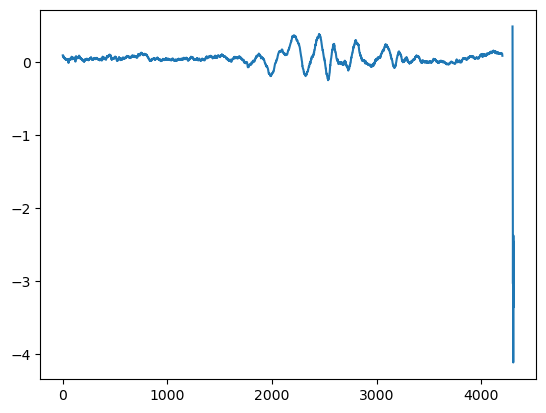

In [40]:
plt.plot(ssh_line.sel(num_lines=slice(4600,None)))

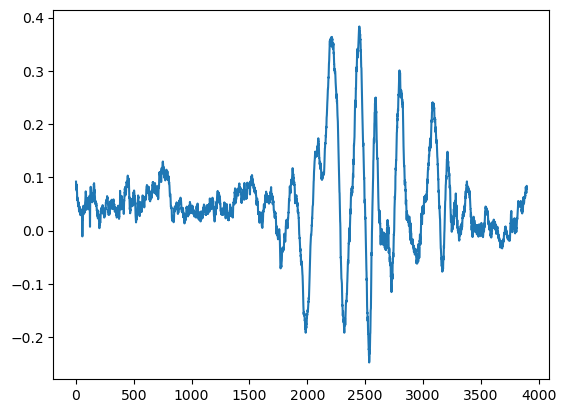

In [41]:
ssh_line = ssh_line.sel(num_lines=slice(4600,8500))
ssh_line = ssh_line.where(np.abs(ssh_line)<1).where(np.isfinite(ssh_line),drop=True)
ssh_line = ssh_line.where(np.isnan(ssh_line)==False,drop=True)
plt.plot(ssh_line)

In [42]:
dx = 2000.0
n = ssh_line.size

x = np.arange(n) * dx


ssh_line = ssh_line.assign_coords(distance=("num_lines", x))
ssh_line = ssh_line.swap_dims({"num_lines": "distance"})

In [43]:
ssh_detrended = xr.DataArray(
    signal.detrend(ssh_line.values),
    dims=["distance"],
    coords={"distance": x},
)

In [44]:
window = signal.windows.hann(n)

ssh_windowed = ssh_detrended * window

In [45]:
xrft.power_spectrum?

Signature:
xrft.power_spectrum(
    da,
    dim=None,
    real_dim=None,
    scaling='density',
    window_correction=False,
    **kwargs,
)
Docstring:
Calculates the power spectrum of da.

.. math::
da' = da - \overline{da}
.. math::
ps = \mathbb{F}(da') {\mathbb{F}(da')}^*

Parameters
----------
da : `xarray.DataArray`
    The data to be transformed
dim : str or sequence of str, optional
    The dimensions along which to take the transformation. If `None`, all
    dimensions will be transformed.
real_dim : str, optional
    Real Fourier transform will be taken along this dimension.
scaling : str, optional
    If 'density', it will normalize the output to power spectral density
    If 'spectrum', it will normalize the output to power spectrum
window_correction : boolean
    If True, it will correct for the energy reduction resulting from applying a non-uniform window.
    This is the default behaviour of many tools for computing power spectrum (e.g scipy.signal.welch and scipy.signal.

In [46]:
fft = xrft.power_spectrum(
    ssh_windowed,
    dim="distance",
    detrend=None,
    #window_correction=False,
    true_phase=False,
    true_amplitude=True,
)

In [47]:
k = fft["freq_distance"]

mask = k > 0

kpos = k.where(mask, drop=True)
psd = fft.where(mask, drop=True)

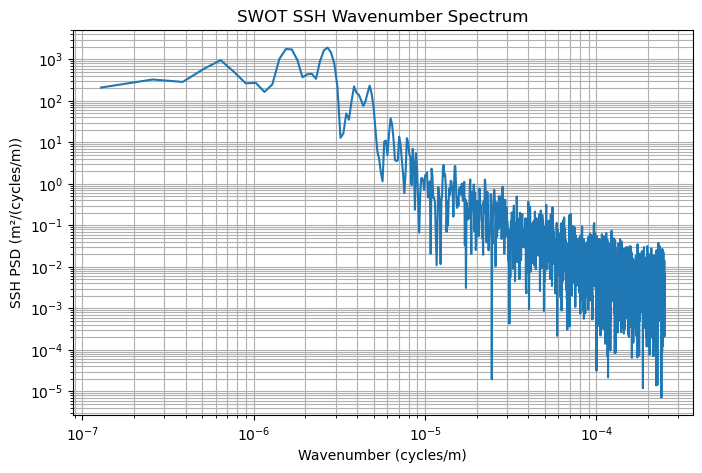

In [48]:
wavelength_km = 1.0 / kpos.values / 1000.0


plt.figure(figsize=(8,5))

plt.loglog(kpos, psd)

plt.xlabel("Wavenumber (cycles/m)")
plt.ylabel("SSH PSD (m²/(cycles/m))")
plt.title("SWOT SSH Wavenumber Spectrum")
plt.grid(True, which="both")

plt.show()


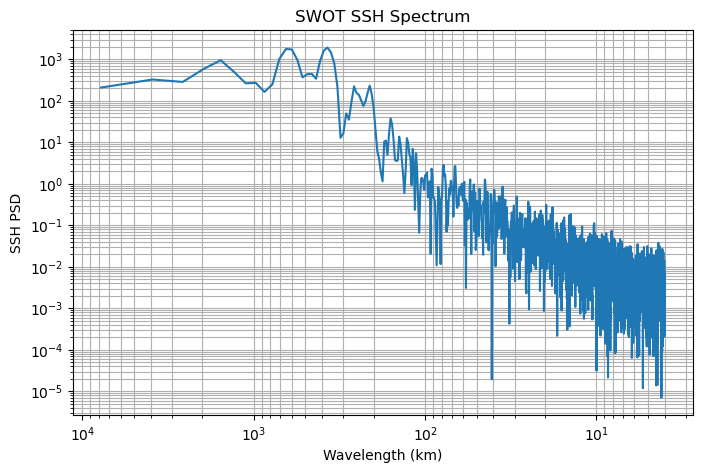

In [49]:

plt.figure(figsize=(8,5))

plt.loglog(wavelength_km, psd)

plt.gca().invert_xaxis()

plt.xlabel("Wavelength (km)")
plt.ylabel("SSH PSD")

plt.title("SWOT SSH Spectrum")
plt.grid(True, which="both")

plt.show()

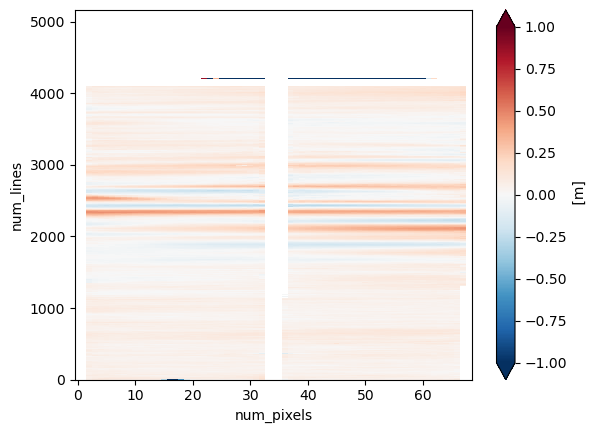

In [50]:
ssh.sel(num_lines=slice(4700,None)).plot(vmax=1)

In [51]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_segments(lon,lat,dat,title,vmin,vmax):
    proj = ccrs.PlateCarree()
    extent = [np.nanmin(lon),
              np.nanmax(lon),
              np.nanmin(lat),
              np.nanmax(lat)]
    
    # Add the scatter plot
    lon=lon.flatten()
    lat=lat.flatten()
    
    fig = plt.figure(figsize=(10,10))
    ax = plt.axes(projection=proj)
    
    im=ax.scatter(lon, lat, c=dat, s=1, cmap=plt.cm.bwr,
                  transform=ccrs.PlateCarree(),
                  vmin=vmin,vmax=vmax )
    # Add the colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', 
                        pad=0.02, aspect=40, shrink=0.8,
                        extend='both' , label='meter')
    ax.coastlines(resolution='10m')
    #ax.add_feature(cfeature.LAND, color='lightgrey')
    #ax.add_feature(cfeature.OCEAN, color='lightblue')
    #ax.add_feature(cfeature.RIVERS)
    gl=ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = gl.right_labels = False
    ax.set_extent(extent, proj)
    ax.set_title(title)
    return ax

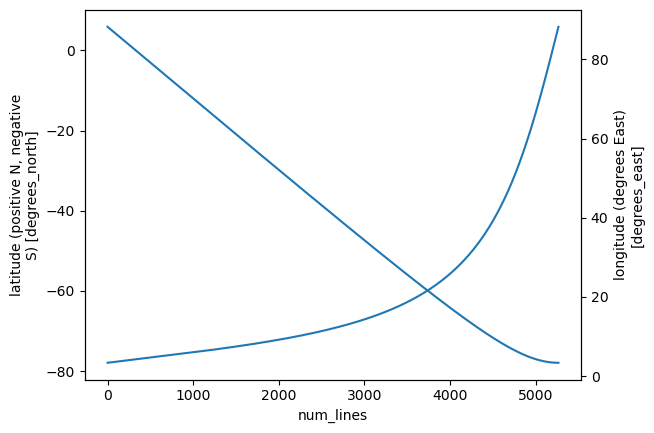

In [59]:
ds.sel(num_pixels=cross_idx).sel(num_lines=slice(4600,None)).latitude.plot()
plt.twinx()
ds.sel(num_pixels=cross_idx).sel(num_lines=slice(4600,None)).longitude.plot()

(-80.0, 5.0)

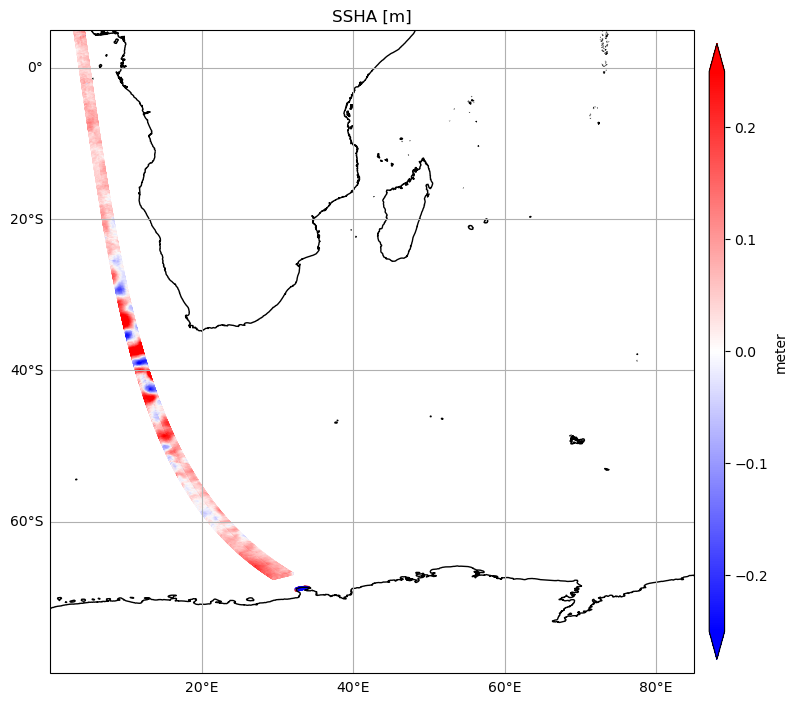

In [60]:
dat = (ds.ssha_karin + ds.height_cor_xover).values
title = 'SSHA [m]'
lon = ds.longitude.where(np.isnan(dat)==False).values
lat = ds.latitude.where(np.isnan(dat)==False).values

vmin, vmax = -0.25,0.25

lonmax = ((ds.longitude.where(np.isnan(dat)==False)+180)%360-180).max()
lonmin = ((ds.longitude.where(np.isnan(dat)==False)+180)%360-180).min()
ax = plot_segments(lon,lat,dat,title,vmin,vmax)
ax.set_xlim(0,85)
ax.set_ylim(-80,5)

In [63]:
ds.time.values

array(['2026-01-06T21:02:32.449588736', '2026-01-06T21:02:32.762636288',
       '2026-01-06T21:02:33.075868800', ...,
       '2026-01-06T21:54:00.020483584', '2026-01-06T21:54:00.334793600',
       '2026-01-06T21:54:00.649309696'],
      shape=(9866,), dtype='datetime64[ns]')